<a href="https://colab.research.google.com/github/c4bae/footy-pitch-tracker/blob/main/footy_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Setup

In [ ]:
!rm -rf sample_data

### Configure HF Access Token

In [ ]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

### Check for GPU Availability

In [ ]:
!nvidia-smi

Wed Jan 14 03:29:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             42W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### Install Whisper and necessary dependencies

In [ ]:
!pip install --upgrade --no-deps --force-reinstall git+https://github.com/openai/whisper.git@v20231117

  Cloning https://github.com/openai/whisper.git (to revision v20231117) to /tmp/pip-req-build-t3iq2cv8
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-t3iq2cv8
  Running command git checkout -q e58f28804528831904c3b6f2c0e473f346223433
  Resolved https://github.com/openai/whisper.git to commit e58f28804528831904c3b6f2c0e473f346223433
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20231117-py3-none-any.whl size=801443 sha256=c64c236ab4f9dd8289cad0c86e4cd5b7ae73233cbef8380fae3629fffc68b601
  Stored in directory: /tmp/pip-ephem-wheel-cache-bdn333sm/wheels/2c/bf/8e/d54006921fb89be3cbd45dea1039b59c066194f3f5504ae5f0
Successfully built openai-whisper


In [ ]:
!pip install whisper-timestamped


INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s et

### Initialize video and audio files

Upload video here

In [ ]:
from pathlib import Path

HOME = Path.cwd()
print("HOME:", HOME)

HOME: /content


Initialize paths

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
SOURCE_VIDEO = HOME / "football.mp4"
SOURCE_FRAMES = HOME / SOURCE_VIDEO.stem
SOURCE_FRAMES.mkdir(parents=True, exist_ok=True)

In [ ]:
TARGET_AUDIO = HOME / "audio.m4a"

In [ ]:
!ffmpeg -i {SOURCE_VIDEO} -vn -acodec copy {TARGET_AUDIO}

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

### Load the Whisper model

In [ ]:
import whisper_timestamped as whisper

model = whisper.load_model("medium")

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [ ]:
import cv2
import json

cap = cv2.VideoCapture(SOURCE_VIDEO)
VIDEO_FPS = cap.get(cv2.CAP_PROP_FPS)

audio = whisper.load_audio(TARGET_AUDIO)

whisper_result = whisper.transcribe(model, audio)

print(json.dumps(whisper_result, indent = 2, ensure_ascii = False))

Detected language: English


100%|██████████| 1144/1144 [00:01<00:00, 736.34frames/s]

{
  "text": " De Bruyne up. Harland! 3! Harland's on a hat-trick already and we've not even reached half-time!",
  "segments": [
    {
      "id": 0,
      "seek": 0,
      "start": 1.28,
      "end": 10.22,
      "text": " De Bruyne up. Harland! 3! Harland's on a hat-trick already and we've not even reached half-time!",
      "tokens": [
        50364,
        1346,
        12792,
        88,
        716,
        493,
        13,
        3653,
        1661,
        0,
        805,
        0,
        3653,
        1661,
        311,
        322,
        257,
        2385,
        12,
        6903,
        618,
        1217,
        293,
        321,
        600,
        406,
        754,
        6488,
        1922,
        12,
        3766,
        0,
        50934
      ],
      "temperature": 0.0,
      "avg_logprob": -0.38915261100320253,
      "compression_ratio": 1.0786516853932584,
      "no_speech_prob": 0.5240960121154785,
      "confidence": 0.755,
      "words": [
        {
 

### Install Sam3 and necessary dependencies

In [ ]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"
%cd /content

fatal: destination path 'sam3' already exists and is not an empty directory.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
  Created wheel for sam3: filename=sam3-0.1.0-0.editable-py3-none-any.whl size=15368 sha256=53dbd2c623923fc84f804505810f5dc79a8fe67ed8394835d44878058e415c62
  Stored in directory: /tmp/pip-ephem-wheel-cache-vourak5i/wheels/7c/90/be/80339bb9db8655024d6c9501da4e5efc6abbda4c897f5a6c43
Successfully built sam3
  Attempting uninstall: sam3
    Found existing installation: sam3 0.1.0
    Uninstalling sam3-0.1.0:
      Successfully uninstalled sam3-0.1.0
/content


In [ ]:
!pip install -q supervision jupyter_bbox_widget

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 17.0 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y cc_torch; TORCH_CUDA_ARCH_LIST="8.0 9.0"; pip install git+https://github.com/ronghanghu/cc_torch
!pip uninstall -y torch_generic_nms; TORCH_CUDA_ARCH_LIST="8.0 9.0"; pip install git+https://github.com/ronghanghu/torch_generic_nms

  Cloning https://github.com/ronghanghu/cc_torch to /tmp/pip-req-build-q53oaw32
  Running command git clone --filter=blob:none --quiet https://github.com/ronghanghu/cc_torch /tmp/pip-req-build-q53oaw32
  Resolved https://github.com/ronghanghu/cc_torch to commit 446e9360ed10d3c8d03925ccb5f220ccb62009de
  Preparing metadata (setup.py) ... done
  Created wheel for cc_torch: filename=cc_torch-0.2-cp312-cp312-linux_x86_64.whl size=322936 sha256=6de51742ad7a33168597aac9dc78a6d68e367a82a6ed3c7ae007a9141ab86a51
  Stored in directory: /tmp/pip-ephem-wheel-cache-yv7lnn4e/wheels/ec/00/d2/dd6e3f726591979dbc35c61d4feb785f48529310b422937236
Successfully built cc_torch
  Cloning https://github.com/ronghanghu/torch_generic_nms to /tmp/pip-req-build-xzqn97ut
  Running command git clone --filter=blob:none --quiet https://github.com/ronghanghu/torch_generic_nms /tmp/pip-req-build-xzqn97ut
  Resolved https://github.com/ronghanghu/torch_generic_nms to commit fcf02b41ea9b37988b244ef80583af17baa4a7f0
  Prepa

## Imports

In [ ]:
import torch

import numpy as np
import supervision as sv

from PIL import Image
from typing import Optional
from IPython.display import Video


from sam3.model_builder import build_sam3_video_predictor

## Promptable Concept Segmentation with Sam3 + S-T-T with Whisper

### Load the Sam3 Model


In [ ]:
DEVICE = [torch.cuda.current_device()]

In [ ]:
predictor = build_sam3_video_predictor(gpus_to_use=[0], bpe_path="/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz")

INFO 2026-01-14 03:47:49,222 4839 sam3_video_predictor.py: 300: using the following GPU IDs: [0]
INFO 2026-01-14 03:47:49,223 4839 sam3_video_predictor.py: 316: 


	*** START loading model on all ranks ***


INFO 2026-01-14 03:47:49,224 4839 sam3_video_predictor.py: 318: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-01-14 03:47:57,904 4839 sam3_video_base.py: 125: setting max_num_objects=10000 and num_obj_for_compile=16


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

INFO 2026-01-14 03:48:15,621 4839 sam3_video_predictor.py: 320: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-01-14 03:48:15,622 4839 sam3_video_predictor.py: 331: 


	*** DONE loading model on all ranks ***




### Process Video

Sam3 analyzes a videos through its frames. We are going to use ffmpeg to divide the given video as its frames, and then store them in the disk.

In [ ]:
!ffmpeg -i {SOURCE_VIDEO} -q:v 2 -start_number 0 {SOURCE_FRAMES}/'%05d.jpg'

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
# Define a function to load a frame for future examples and tests

def load_frame(directory: str, index: int):
    directory_path = Path(directory)
    frame_path = directory_path / f"{index:05d}.jpg"  # 05d is formatting: index = 1 -> 00001.jpg

    if not frame_path.exists():
        raise FileNotFoundError(f"Frame not found: {frame_path}")

    frame = cv2.imread(str(frame_path))
    if frame is None:
        raise FileNotFoundError(f"Failed to read frame: {frame_path}")

    return frame  # Numpy array

### Begin Video Inference Session

To process videos using Sam3, an inference session must be initialized on the source video. During initializations, all frames are frames are processed, and their features are stored in the session state specified by the session_id.

In [ ]:
response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=Path(SOURCE_FRAMES).as_posix(),
    )
)

session_id = response["session_id"]

frame loading (image folder) [rank=0]: 100%|██████████| 286/286 [00:09<00:00, 28.88it/s]


In [ ]:
# Reset to maintain a clean slate

_ = predictor.handle_request(
    request=dict(
        type="reset_session",
        session_id=session_id,
    )
)

## Initialize a text prompt
Here we use the prompt to detect all instances of that "object" within the video. Sam3 will assign a unique ID to each found instance. Furthermore, Sam3 will remember this prompt due to the session id.

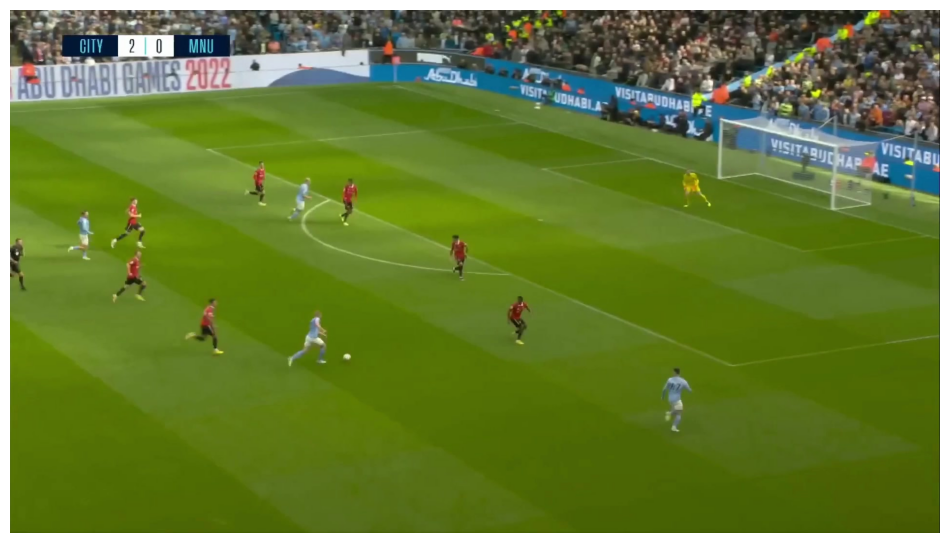

In [ ]:
frame_idx = 0
frame = load_frame(SOURCE_FRAMES, frame_idx)

sv.plot_image(frame)

In [ ]:
text = "footballer with blue jersey"

response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        text=text,
    )
)

# Sample result
result = response["outputs"]

## Produce final results
For visualization, we employ the supervision package from RoboFlow for ease. Furthermore, Whisper will be used here to analyze the commentary.

In [ ]:
def from_sam(result: dict) -> sv.Detections:
    return sv.Detections(
        xyxy=sv.mask_to_xyxy(result["out_binary_masks"]),  # Returns tightest possible rectangle around object
        mask=result["out_binary_masks"],  # Returns mask of object (pixel accurate)
        confidence=result["out_probs"],  # Probability of correct object
        tracker_id=result["out_obj_ids"],  # Assigns unique id to object
    )

In [ ]:
COLOR = sv.ColorPalette.from_hex(["#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"])

In [ ]:
def annotate(image: np.ndarray, detections: sv.Detections, text = None, smart_position = True) -> np.ndarray:
    h, w, _ = image.shape  # image.shape returns height, width, # of color channels (usually 3, BGR
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=(w, h))

    mask_annotator = sv.MaskAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.TRACK,
        opacity=0.6,
    )

    annotated_image = image.copy()
    annotated_image = mask_annotator.annotate(annotated_image, detections)

    if text:
        label_annotator = sv.LabelAnnotator(
            color=COLOR,
            color_lookup=sv.ColorLookup.TRACK,
            text_scale=text_scale,
            text_color=sv.Color.BLACK,
            text_position=sv.Position.TOP_CENTER,
            text_offset=(0,-30),
            smart_position=smart_position, # smart_position prevents overlap
            # between labels
        )
        labels = [
            f"#{ids_to_jerseys[str(tracker_id)]}"
            for tracker_id in detections.tracker_id
        ]
        annotated_image = label_annotator.annotate(annotated_image, detections, labels)

    return annotated_image

### Establish footballer-id connections

Due to a lack of data for each "highlight" video, the user must manually correspond each tracker_id with the footballer's jersey number.

In [ ]:
ids_to_jerseys = {
    '4': 'Ake',
    '1': 'De Bruyne',
    '2': 'Grealish',
    '3': 'Haaland',
    '5': 'X',
    '0': 'Foden',
    '7': 'Silva',
    '6': 'Who?',
    '8': '8',
}

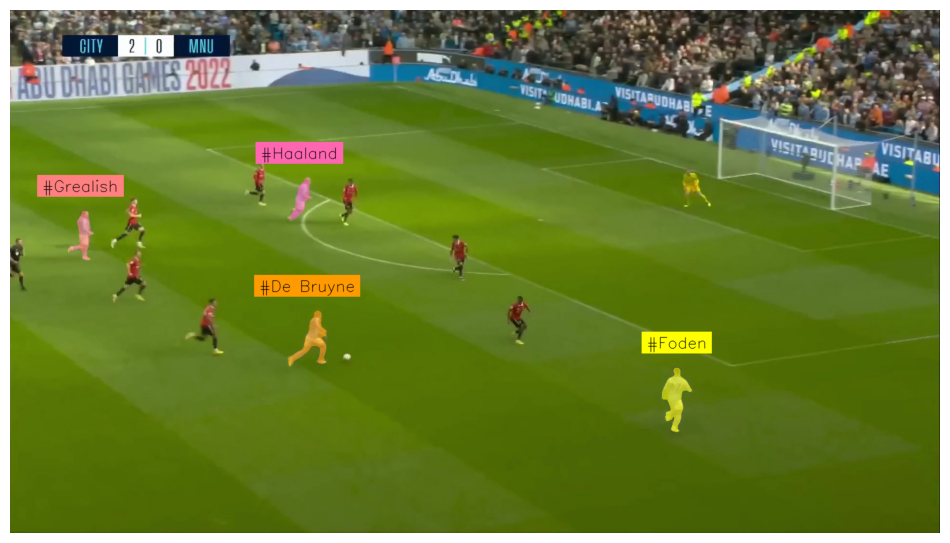

In [ ]:
# Test if Sam3 Model is working with sample frame

detections = from_sam(result)

annotated_frame = annotate(frame, detections, text)

sv.plot_image(annotated_frame)

### Propagate segmentation in video


In [ ]:
def propagate_in_video(predictor, session_id):
    frame_outputs = {}
    for response in predictor.handle_stream_request(
        request = dict(
            type="propagate_in_video",
            session_id=session_id,
        )
    ):
        frame_outputs[response["frame_index"]] = response["outputs"]

    return frame_outputs

In [ ]:
frame_outputs = propagate_in_video(predictor, session_id)

propagate_in_video:   0%|          | 0/286 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

In [ ]:
current_player = "De Bruyne"

def callback(frame: np.ndarray, index: int) -> np.ndarray:
    global current_player
    output = frame_outputs[index]
    detections = from_sam(output)
    player = name_frames.get(index, 0)

    tracker_id = -1
    for id in ids_to_jerseys.keys():
      if player == 0:
        if current_player == ids_to_jerseys[id]:
          tracker_id = int(id)
          break

      if player == ids_to_jerseys[id]:
        current_player = player
        tracker_id = int(id)
        break

    return annotate(frame, detections[detections.tracker_id == tracker_id], text)

### Establish dictionary of each player's first name, last name, nicknames,


In [ ]:
player_names = {
    # --- Forwards ---
    "Haaland": [
        'Erling', 'Haaland', 'Erling Haaland', 'Håland',
        'Harland', 'Holland', 'Irling',
        'The Robot', 'Terminator', 'Daemon', 'Viking',
        'Number Nine', 'Nine', 'Robot'
    ],
    "Grealish": [
        'Jack', 'Grealish', 'Jack Grealish', 'Greelish',
        'Super Jack', 'Jackie', 'Grealish',
        'Number Ten', 'The Ten'
    ],
    "Foden": [
        'Phil', 'Foden', 'Phil Foden', 'Philip Foden',
        'Stockport Iniesta', 'The Sniper',
        'Number Forty Seven', 'Four Seven'
    ],
    "Doku": [
        'Jeremy', 'Doku', 'Jeremy Doku', 'Docu',
        'The Flash', 'Jez',
        'Number Eleven'
    ],
    "Savinho": [
        'Savio', 'Savinho', 'Moreira de Oliveira',
        'Sávio', 'Savio',
        'Number Twenty Six'
    ],
    "Alvarez": [
        'Julian', 'Alvarez', 'Julian Alvarez',
        'La Arana', 'The Spider', 'Spider',
        'Number Nineteen'
    ],
    "Mahrez": [
        'Riyad', 'Mahrez', 'Riyad Mahrez', 'Marez',
        'Gloves', 'The Algerian',
        'Number Twenty Six'
    ],

    # --- Midfielders ---
    "De Bruyne": [
        'Kevin', 'De Bruyne', 'Kevin De Bruyne', 'KDB',
        'Ginger Prince', 'King Kev', 'Debruyne', 'De Browner',
        'Number Seventeen', 'Captain', 'De', 'Bruyne'
    ],
    "Rodri": [
        'Rodrigo', 'Rodri', 'Rodrigo Hernandez', 'Rodri Hernandez',
        'Godri', 'Fireman', 'CDM',
        'Number Sixteen'
    ],
    "Bernardo": [
        'Bernardo', 'Silva', 'Bernardo Silva',
        'Bubblegum', 'Little Magician',
        'Number Twenty'
    ],
    "Gundogan": [
        'Ilkay', 'Gundogan', 'Ilkay Gundogan', 'Gundo',
        'Mr Whippy', 'Silky Ilkay',
        'Number Eight', 'Number Nineteen'
    ],
    "Kovacic": [
        'Mateo', 'Kovacic', 'Mateo Kovacic', 'Kova',
        'Number Eight'
    ],
    "Nunes": [
        'Matheus', 'Nunes', 'Matheus Nunes',
        'Number Twenty Seven'
    ],

    # --- Defenders ---
    "Dias": [
        'Ruben', 'Dias', 'Ruben Dias', 'Rúben Dias',
        'Father', 'The Wall',
        'Number Three'
    ],
    "Stones": [
        'John', 'Stones', 'John Stones',
        'Johnny Boulders', 'Barnsley Beckenbauer',
        'Number Five'
    ],
    "Walker": [
        'Kyle', 'Walker', 'Kyle Walker',
        'Pace Merchant',
        'Number Two'
    ],
    "Ake": [
        'Nathan', 'Ake', 'Nathan Ake', 'Akay',
        'The Dutchman',
        'Number Six'
    ],
    "Akanji": [
        'Manuel', 'Akanji', 'Manuel Akanji',
        'Manu',
        'Number Twenty Five'
    ],
    "Gvardiol": [
        'Josko', 'Gvardiol', 'Josko Gvardiol', 'Guardiola', 'Gwar-dee-ol',
        'Little Pep',
        'Number Twenty Four'
    ],
    "Lewis": [
        'Rico', 'Lewis', 'Rico Lewis',
        'Number Eighty Two'
    ],
}

### Store Footballer name across frame

Each frame will highlight the most recently said name by the commentator.

In [ ]:
name_frames = {}
for wordset in whisper_result["segments"][0]["words"]:
    for name, aliases in player_names.items():
        if not str.isalpha(wordset["text"]):
          wordset["text"] = wordset["text"][:-1]

        if wordset["text"] in aliases:
          name_frames[int(wordset["start"]) * VIDEO_FPS - 5] = name
          break

print(name_frames)

{20.0: 'De Bruyne', 45.0: 'Haaland', 120.0: 'Haaland'}


### Create video

In [ ]:
TARGET_VIDEO = f"{Path(SOURCE_VIDEO).stem}-result{Path(SOURCE_VIDEO).suffix}"

In [ ]:
sv.process_video(source_path=SOURCE_VIDEO, target_path=TARGET_VIDEO, callback=callback)

In [ ]:
Video(TARGET_VIDEO, embed=True, width=1080)

### Combine video and audio into one video

In [ ]:
!ffmpeg -i {TARGET_VIDEO} -i {TARGET_AUDIO} -c:v copy -c:a aac -map 0:v:0 -map 1:a:0 result.mp4 -y

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
Video("result.mp4", embed=True, width=1080)